## WandB

In [99]:
import wandb
import pandas as pd
wandb.login()
from pathlib import Path

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches._paths import FIG_PATH
from graph_transformer_long_range_niches.pl.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_parameter_space

ImportError: cannot import name 'plot_parameter_space' from 'graph_transformer_long_range_niches.pl.wandb' (/ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/graph_transformer_long_range_niches/pl/wandb.py)

# Load Wandb paths

In [100]:
FIG_PATH_WANDB = Path(FIG_PATH, 'legnini23', 'wandb')

In [2]:
Legnini_GNN_crossgene_experiment = "ph9oavs9"
Legnini_GNNTrans_crossgene_experiment = "32e8lneu"

Legnini_GNN_crossgene_parameter = "u6kgtinv"
Legnini_GNNTrans_crossgene_parameter = "ghm3evf5"

## Parameter space

- Plot the performance as function of the total parameters. Can we see a stagnation at some point?
  

In [135]:
df_gnn_parameter = load_result_as_df(Legnini_GNN_crossgene_parameter, 'parameter')
df_gnntrans_parameter = load_result_as_df(Legnini_GNNTrans_crossgene_parameter, 'parameter')

In [136]:
df_gnn_parameter.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_r2,test_pearson_corr,gnn_num_layers,gnn_hidden_dim,embed_dim
0,7otqetyt,legnini23_None_sample_1_44_gnn,None,finished,None,None,None,148.844120,14952,0.719020,0.896127,2,128,16
1,a50u0cr8,legnini23_None_sample_1_44_gnn,None,finished,None,None,None,236.340373,111192,0.765008,0.916640,2,256,256
2,7j16hpjt,legnini23_None_sample_1_44_gnn,None,finished,None,None,None,134.578983,8232,0.710843,0.884777,2,64,16
3,bddudx0w,legnini23_None_sample_1_44_gnn,None,finished,None,None,None,158.203854,33912,0.758174,0.913881,2,32,256
4,57odd6fm,legnini23_None_sample_1_44_gnn,None,finished,None,None,None,344.543488,55272,0.720645,0.883982,2,512,16


In [72]:
df_gnntrans_parameter.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_r2,test_pearson_corr,gnn_num_layers,embed_dim,trans_n_heads,trans_num_layers
0,273o3ogz,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1493.056613,351280,0.741072,0.907089,2,128,2,4
1,7ki7esjf,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1728.725483,883248,0.805813,0.933463,2,256,4,2
2,myiis88q,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1751.270448,618768,0.611089,0.819073,4,32,4,2
3,ishtfjz0,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,957.564408,159568,0.757038,0.903194,4,128,4,1
4,0wsdwkms,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,897.674231,408048,0.690270,0.867948,4,256,4,1


In [127]:
def plot_parameter_space(df: pd.DataFrame, 
                         metrics: str = 'test_r2', 
                         relevant_params = [],
                         save_path: str = None):

    # Apply LOWESS smoothing
    smoothed = lowess(df[metrics], df['total_parameters'], frac=0.4)  # frac controls smoothness
    # Create scatterplot with trend line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='total_parameters', y=metrics, data=df, label='Data Points')
    
    # Plot smoothed trend
    plt.plot(smoothed[:, 0], smoothed[:, 1], color='red', label='LOWESS Curve')
    
    # Labels and title
    plt.xlabel("Total Parameters")
    plt.ylabel(f"{metrics}")
    plt.title(f"Trend of {metrics} with Increasing Parameters")
    
    if save_path is not None:
        plt.savefig(f'{save_path}_total_parameters_vs_{metrics}.jpg', dpi=1200)
    
    plt.show()

    if len(relevant_params) > 0:
        g = sns.pairplot(df_gnntrans_parameter, x_vars=relevant_params, y_vars=['test_r2'], kind='reg', height=4)
        if save_path is not None:
            g.savefig(f'{save_path}_relevantParams_vs_{metrics}.jpg', dpi=1200)

        plt.show()

    if save_path is not None:
        print(f'Saved figures to {save_path}')

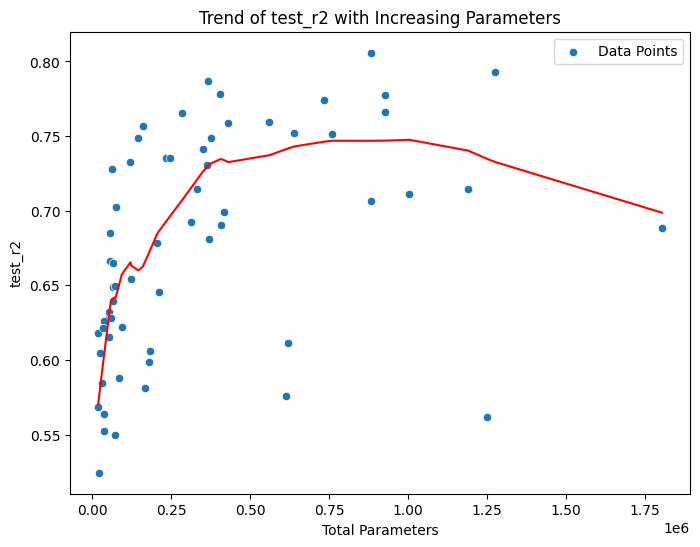

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


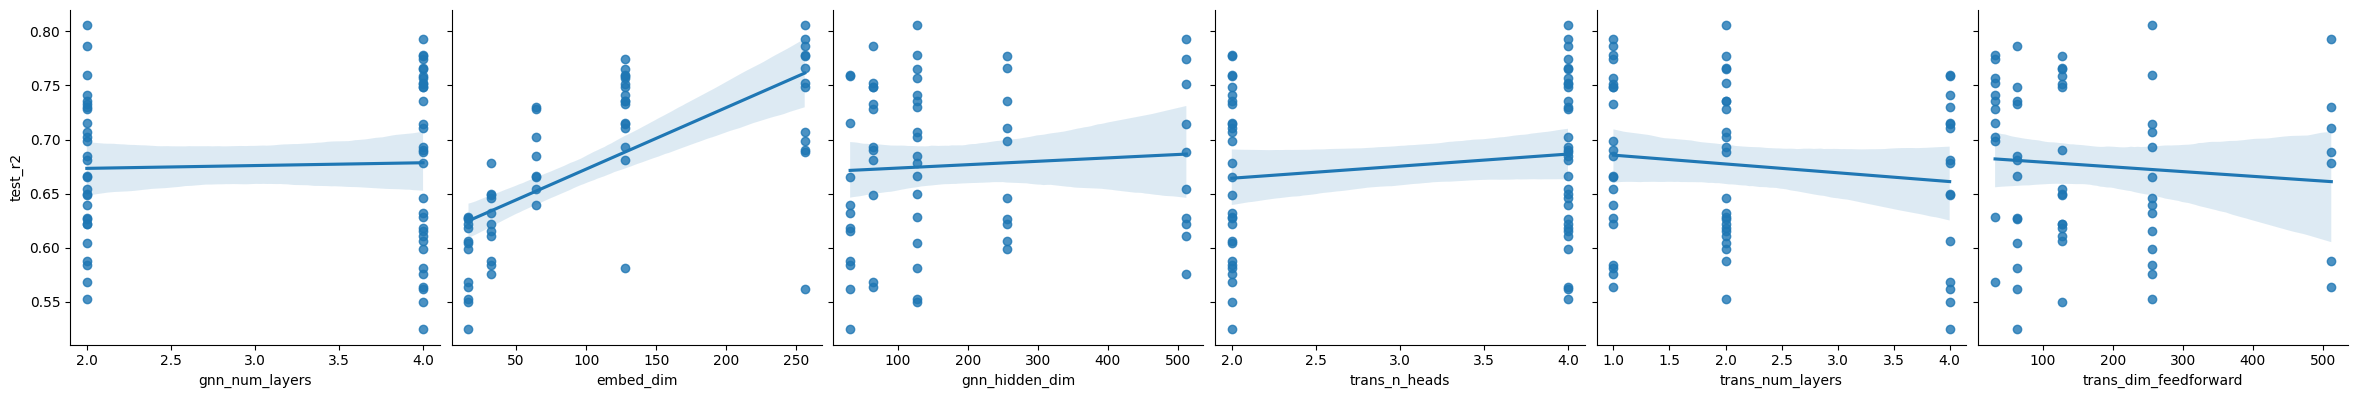

Saved figures to /home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/wandb/ghm3evf5


In [139]:
plot_parameter_space(df_gnntrans_parameter, relevant_params = ['gnn_num_layers', 'embed_dim', 'gnn_hidden_dim', 'trans_n_heads', 'trans_num_layers', 'trans_dim_feedforward'] , save_path = f'{FIG_PATH_WANDB}/{Legnini_GNNTrans_crossgene_parameter}')

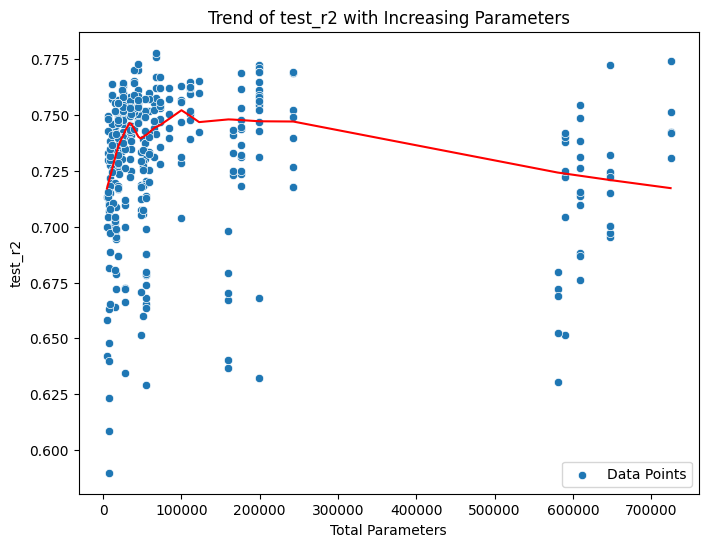

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


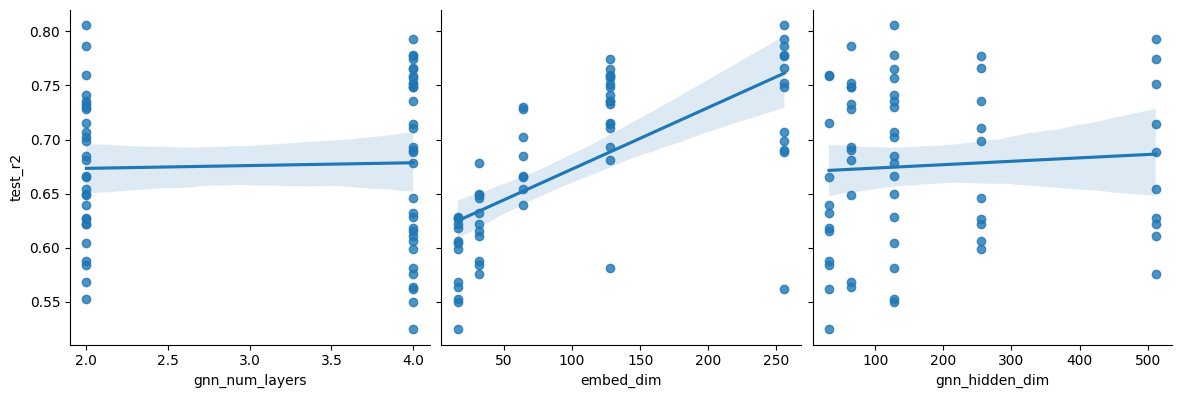

Saved figures to /home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/wandb/u6kgtinv


In [140]:
plot_parameter_space(df_gnn_parameter, relevant_params = ['gnn_num_layers', 'embed_dim', 'gnn_hidden_dim'] , save_path = f'{FIG_PATH_WANDB}/{Legnini_GNN_crossgene_parameter}')

## Robustness

In [7]:
df_gnn = load_result_as_df(Legnini_GNN_crossgene_experiment)
df_agg_gnn = compute_mean_and_std(df_gnn)
df_agg_gnn.head()

<Run francesca-drummer/InterScale_hyperparameter_sweep/4ppb5o5v (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/eeeq9hbz (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/fyowh8kt (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/ip93zaw3 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/7ryi7znx (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/71oenkx3 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/enjz1cmv (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/zudypyuc (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/rpokp12a (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/usntsxi0 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/k1z690gp (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/8iq1dpl0 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/sxkac680 (finished)>
<Run frances

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.215774,0.428353,0.463107,0.405967,248.121250,191.150328
1,0.0,0,nonlinear,0.384891,0.373139,0.632855,0.318335,304.415826,146.998133
2,0.0,100,linear,0.200444,0.468355,0.425370,0.454796,248.669297,190.998759
3,0.0,100,nonlinear,0.386292,0.384239,0.596542,0.405699,332.892815,167.689622
4,0.0,200,linear,0.355759,0.372503,0.588741,0.360033,330.627940,178.721700


In [6]:
df_gnntrans = load_result_as_df(Legnini_GNNTrans_crossgene_experiment)
df_agg_gnntrans = compute_mean_and_std(df_gnntrans)
df_agg_gnntrans.head()

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.699093,0.046392,0.861675,0.021734,786.298800,84.134047
1,0.0,0,nonlinear,0.654882,0.096546,0.839183,0.031326,820.913805,259.135376
2,0.0,100,linear,0.647288,0.012335,0.834025,0.004402,980.877279,54.422655
3,0.0,100,nonlinear,0.669093,0.071966,0.838927,0.042680,939.264290,70.730966
4,0.0,200,linear,0.672303,0.074135,0.839908,0.047444,1000.655693,215.823289


In [16]:
def plot_robustness(df, metric = "test_r2"):
    plt.figure(figsize=(4, 6))
    sns.lineplot(
        data=df,
        x="radius",
        y=metric,
        hue="pct_mask_nodes",
        marker="o",
        palette="coolwarm",
        errorbar=("sd")  # Adds standard deviation as shaded region
    )
    
    # Formatting
    plt.xlabel("Radius")
    plt.legend(title="Pct Mask Nodes")
    if metric == "runtime_seconds":
        plt.ylim(0, 1500)  # Set y-axis range
        plt.ylabel("Mean runtime in seconds")
    else:
        plt.ylim(0, 1)  # Set y-axis range
        plt.ylabel("Mean Test R² Score")
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()

In [9]:
df_linear_gnntrans = summary_df(df_gnntrans, "test_r2", decoder_type = "linear")

linear Decoder Summary (test_r2:
    radius  pct_mask_nodes  mean_test_r2  std_test_r2  mean_run_time  \
0        0            0.00      0.699093     0.046392     786.298800   
1        0            0.10      0.690599     0.056229    1010.803082   
2        0            0.25      0.674682     0.044393     812.447855   
3        0            0.50      0.661472     0.029549     867.981104   
4      100            0.00      0.647288     0.012335     980.877279   
5      100            0.10      0.686377     0.034877    1073.059548   
6      100            0.25      0.678638     0.051307     831.746268   
7      100            0.50      0.738730     0.009166     797.078852   
8      200            0.00      0.672303     0.074135    1000.655693   
9      200            0.10      0.673050     0.060085     840.381074   
10     200            0.25      0.666062     0.025290     791.906555   
11     200            0.50      0.682316     0.081635     808.085285   
12     300            0.00     

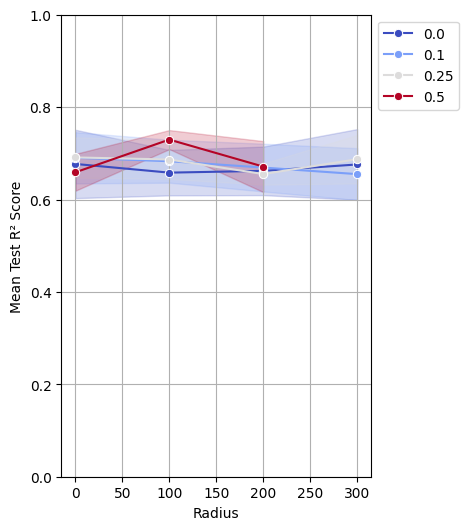

In [10]:
plot_robustness(df_gnntrans)

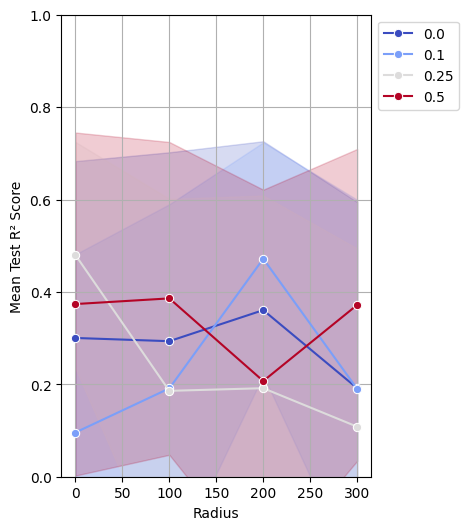

In [11]:
plot_robustness(df_gnn)

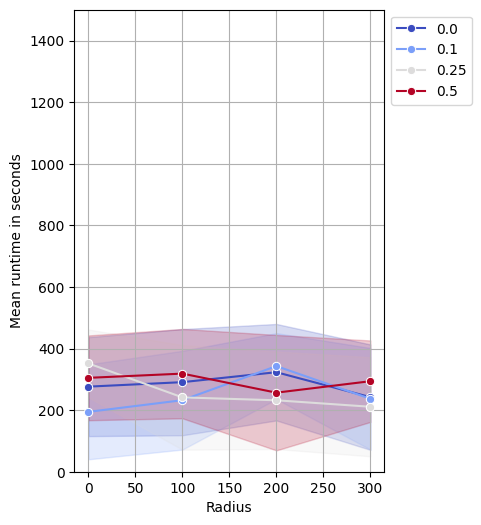

In [18]:
plot_robustness(df_gnn, 'runtime_seconds')

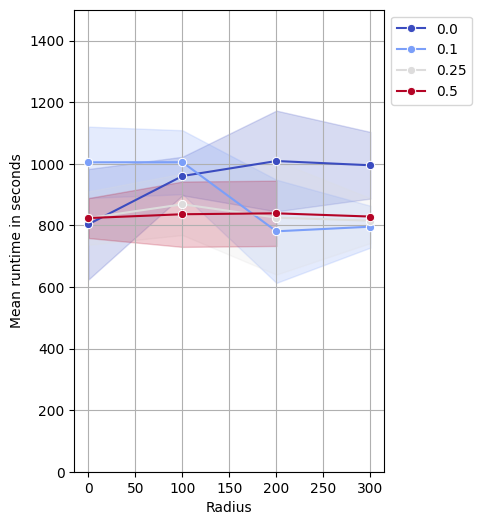

In [17]:
plot_robustness(df_gnntrans, 'runtime_seconds')